# Lab 8 — Navigation World Model:记忆与模型驱动的导航

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab08_navigation_world_model/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 8**

在此之前的 Lab 里,agent 都能(带噪地)读到**全局状态** —— Lab 0/4 的小球坐标是直接给的。但真实导航任务中,robot 每一刻只能看到**局部视野**(local view),goal 藏在从未见过的区域。本 Lab 在一个自实现的 2D grid world 里回答一个问题:**导航到底需要多少"内部状态"?**

我们实现并正面对比三种 agent(核心教学点):

1. **Reactive Agent** — 只看当前 5×5 观测,greedy + 惯性随机游走,没有任何记忆;
2. **Agent with Memory** — 维护一张逐渐填充的全局 **occupancy map**(spatial memory),在记忆地图上做 **BFS** 规划与 frontier 探索;
3. **Agent with World Model** — 在记忆之上加一个**学习型 forward model**,预测"执行动作后局部观测会变成什么样",从而把规划**延伸到尚未见过的区域**(想象规划)。

核心链路:**Observation → State Estimation(odometry)→ Memory / Map → World Model → Planning → Action**。

## 1. Motivation:为什么导航不能只靠"当下所见"?

**Why this matters:** grid world 里 agent 的观测是一个以自身为中心的 5×5 窗口 —— 这是典型的 **partial observability**(POMDP)。当前 observation 不告诉你"我从哪来、刚才那个岔路口另一边是什么、goal 在哪个方向"。只靠当前帧做决策的 reactive agent 会在墙角和走廊里**反复兜圈子**,因为它没有任何东西能记住"这里我来过"。

本 Lab 的三个关键词对应课程的三层概念:

- **State / State Estimation** —— 真实状态(grid + 位姿 + goal)对 agent 不可见;agent 用 **odometry**(积分自己的动作 + 碰撞反馈)估计位姿,这是把观测"钉"到地图上的前提;
- **Memory / Spatial Representation** —— 一张 allocentric(世界坐标系)的 occupancy map 就是最朴素的空间记忆:见过即是已知。它让 agent 不再重复探索,也让 BFS/A* 这类**图规划**成为可能;
- **World Model** —— memory 只能告诉你"**见过**什么";model 让你对"**没见过**什么"做出有根据的猜测。有了它,规划器可以穿越未知区域走捷径、优先探索模型预测为开阔的方向 —— 代价是引入 **model error**,而当世界统计分布改变(**OOD**)时,这种自信会变成失败。

## 2. Setup

**Why this cell exists:** 除科学计算栈外只需要 `imageio`(写 GIF);Colab 已预装 torch / numpy / matplotlib,下面的 cell 按需补装,保证 notebook 在 Colab 与本地行为一致。

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["imageio"]:
    ensure(pkg)

import os, time, heapq
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import imageio.v2 as imageio
import torch
import torch.nn as nn
from IPython.display import Image, display

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
device = "cpu"  # 全 Lab 纯 CPU 即可
T0 = time.time()
print("torch", torch.__version__, "| numpy", np.__version__, "| device", device)

torch 2.8.0 | numpy 2.0.2 | device cpu


## 3. Environment & Dataset

### 3.1 环境:partial observability 的 2D grid world

**设计要点(全部手写、无 gym 依赖):**

- **世界**:25×25 grid,四周是墙,内部随机生成若干矩形障碍物;start 与 goal 随机采样(保证连通、曼哈顿距离 ≥ 20);
- **观测**:以 agent 为中心的 **5×5 窗口**(`view_radius=2`),值域 `{0 free, 1 wall, 2 goal}` —— goal 只有走进视野才"存在";
- **动作**:上 / 下 / 左 / 右四向移动;撞墙则原地不动;
- **odometry 反馈**:`step()` 返回 `info["moved"]`(本步是否真的移动了)—— 这是 agent 做 state estimation 的唯一本体感觉(proprioception)。注意 env **永远不返回全局坐标**;`env.pos` 只供评估与画图使用,agent 禁止访问。

In [2]:
UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACT_NAMES = ["up", "down", "left", "right"]
UNKNOWN, FREE, WALL = -1, 0, 1   # memory map 的值域;UNKNOWN 只存在于 agent 的脑中
STAY = 4                          # 仅供 world model 查询用的"原地不动"动作

def _reachable(grid, start, goal):
    """BFS flood: start 是否能走到 goal(仅走 free cell)。"""
    H, W = grid.shape
    seen = np.zeros((H, W), bool); seen[start] = True
    stack = [tuple(start)]
    while stack:
        r, c = stack.pop()
        if (r, c) == tuple(goal):
            return True
        for dr, dc in DELTAS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and grid[nr, nc] == 0 and not seen[nr, nc]:
                seen[nr, nc] = True; stack.append((nr, nc))
    return False

def generate_map(H, W, n_rects, rng, min_dist, max_tries=300):
    """随机矩形障碍物地图,拒绝采样直到 start/goal 连通且足够远。"""
    for _ in range(max_tries):
        grid = np.zeros((H, W), dtype=np.int64)
        grid[0, :] = grid[-1, :] = 1; grid[:, 0] = grid[:, -1] = 1
        for _ in range(n_rects):
            h, w = rng.integers(2, 5), rng.integers(2, 5)
            r, c = rng.integers(1, H - h - 1), rng.integers(1, W - w - 1)
            grid[r:r + h, c:c + w] = 1
        frees = np.argwhere(grid == 0)
        i, j = rng.choice(len(frees), size=2, replace=False)
        start, goal = tuple(frees[i]), tuple(frees[j])
        if abs(start[0] - goal[0]) + abs(start[1] - goal[1]) < min_dist:
            continue
        if _reachable(grid, start, goal):
            return grid, start, goal
    raise RuntimeError("map generation failed")

class GridNavEnv:
    """2D grid navigation with partial observability.

    reset() / step(action) -> obs, done, info
      obs  : (2R+1, 2R+1) window centered on the agent, values {0 free, 1 wall, 2 goal}
      info : {"moved": bool, ...}  —— odometry 反馈,agent 唯一的位姿线索
    全局坐标(env.pos)是 hidden state,仅评估/可视化可用。
    """
    def __init__(self, grid, start, goal, view_radius=2, max_steps=400):
        self.grid = grid
        self.start, self.goal = tuple(start), tuple(goal)
        self.R, self.max_steps = view_radius, max_steps
        self.H, self.W = grid.shape

    def reset(self):
        self.pos, self.t = self.start, 0
        return self._obs()

    def _obs(self):
        R = self.R
        win = np.ones((2 * R + 1, 2 * R + 1), dtype=np.int64)  # 越界视为 wall
        r0, c0 = self.pos
        for i in range(2 * R + 1):
            for j in range(2 * R + 1):
                gr, gc = r0 - R + i, c0 - R + j
                if 0 <= gr < self.H and 0 <= gc < self.W:
                    win[i, j] = 2 if (gr, gc) == self.goal else self.grid[gr, gc]
        return win

    def step(self, action):
        dr, dc = DELTAS[action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc
        moved = False
        if 0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0:
            self.pos = (nr, nc); moved = True
        self.t += 1
        done = (self.pos == self.goal) or (self.t >= self.max_steps)
        return self._obs(), done, {"moved": moved, "success": self.pos == self.goal}

### 3.2 Smoke test:看一眼"世界全貌"与"agent 所见"的差距

左图是 **god's view**(agent 永远看不到);右图是它实际拿到的 5×5 观测。所有困难都来自这两张图之间的信息差。

map (25, 25) | start (np.int64(10), np.int64(16)) | goal (np.int64(1), np.int64(2)) | obs window (5, 5)
t=0  moved=True  (agent 只能看到窗口,看不到自己在哪)
t=1  moved=True  (agent 只能看到窗口,看不到自己在哪)
t=2  moved=True  (agent 只能看到窗口,看不到自己在哪)
t=3  moved=True  (agent 只能看到窗口,看不到自己在哪)


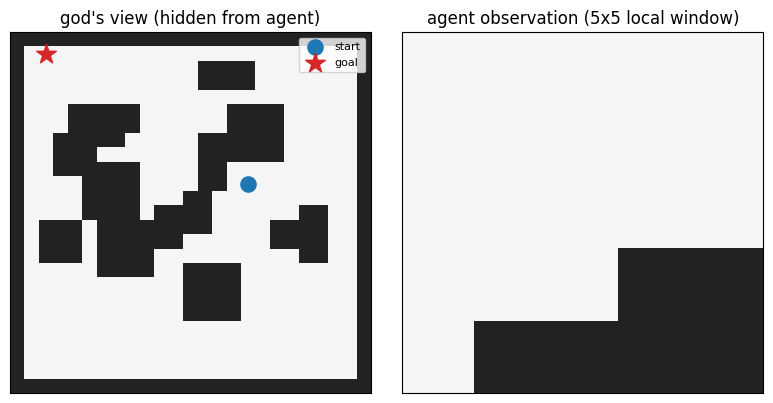

In [3]:
R_VIEW = 2
viz_rng = np.random.default_rng(7)
grid, start, goal = generate_map(25, 25, n_rects=14, rng=viz_rng, min_dist=20)
env = GridNavEnv(grid, start, goal, view_radius=R_VIEW, max_steps=300)
obs = env.reset()
print(f"map {grid.shape} | start {start} | goal {goal} | obs window {obs.shape}")
for t in range(4):
    obs, done, info = env.step(int(np.random.default_rng(t).integers(4)))
    print(f"t={t}  moved={info['moved']}  (agent 只能看到窗口,看不到自己在哪)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(grid, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]), origin="upper")
axes[0].scatter(*start[::-1], marker="o", c="#1f77b4", s=120, label="start")
axes[0].scatter(*goal[::-1], marker="*", c="#d62728", s=220, label="goal")
axes[0].set_title("god's view (hidden from agent)"); axes[0].legend(loc="upper right", fontsize=8)
axes[1].imshow(obs, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222", "#2ca02c"]),
               origin="upper", vmin=0, vmax=2)
axes[1].set_title("agent observation (5x5 local window)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("assets/env_teaser.png", dpi=110); plt.show()

### 3.3 Dataset:为 forward model 准备 (window, action) → next window 数据

**Why:** world model 要学的是 observation space 里的 transition:**给定当前局部窗口和动作,预测下一个局部窗口**。关键设计:

- **动作 = 移动**时,next window 是窗口平移后的结果 —— 新进入视野的那一列/行 cell 在输入里**从未出现过**,模型必须根据上下文(障碍物的局部纹理)去"脑补"它们。这正是"预测未见区域"的能力来源;
- **动作 = STAY(查询)**时,next window = 当前窗口本身 —— 但训练时输入窗口被随机 mask 成 `UNKNOWN`,目标仍是完整真值。这教模型做 **map completion**(把记忆地图里的未知 cell 填上预测占据);
- 撞墙时 agent 原地不动,因此 target 是不动的窗口 —— 数据里天然包含"墙挡路"的 transition。

这些数据全部来自**训练地图**(与后面的测试地图不同 seed),随机采样 (位置, 动作, mask) 三元组,无需真的 rollout agent。

In [4]:
def window_of(grid, r, c, R):
    """取以 (r,c) 为中心的 (2R+1)^2 窗口;越界填 wall。grid 可含 UNKNOWN(-1)。"""
    H, W = grid.shape
    out = np.ones((2 * R + 1, 2 * R + 1), dtype=np.int64)
    for i in range(2 * R + 1):
        for j in range(2 * R + 1):
            gr, gc = r - R + i, c - R + j
            if 0 <= gr < H and 0 <= gc < W:
                out[i, j] = grid[gr, gc]
    return out

def make_model_dataset(n_maps, samples_per_map, H=25, W=25, n_rects=14, R=2, seed=0):
    """返回 X_win (N,5,5)∈{-1,0,1}, X_act (N,), Y (N,5,5)∈{0,1}。"""
    rng = np.random.default_rng(seed)
    X_win, X_act, Y = [], [], []
    for _ in range(n_maps):
        g, _, _ = generate_map(H, W, n_rects, rng, min_dist=15)
        frees = np.argwhere(g == 0)
        for _ in range(samples_per_map):
            r, c = frees[rng.integers(len(frees))]
            a = int(rng.integers(5))  # 含 STAY 查询动作
            dr, dc = DELTAS[a] if a < 4 else (0, 0)
            nr, nc = r + dr, c + dc
            if not (0 <= nr < H and 0 <= nc < W) or g[nr, nc] == 1:
                nr, nc = r, c  # 撞墙/越界 → 原地不动
            win_in = window_of(g, r, c, R).astype(np.int64)
            mask = rng.random(win_in.shape) < rng.uniform(0.0, 0.6)  # 模拟"记忆不全"
            win_in[mask] = UNKNOWN
            X_win.append(win_in)
            X_act.append(a)
            Y.append(window_of(g, nr, nc, R).astype(np.int64))  # 完整真值
    return np.array(X_win), np.array(X_act), np.array(Y)

Xtr, Atr, Ytr = make_model_dataset(48, 400, R=R_VIEW, seed=0)
Xva, Ava, Yva = make_model_dataset(8, 400, R=R_VIEW, seed=999)
PRIOR_FREE = float((Ytr == FREE).mean())
print(f"train {Xtr.shape} | val {Xva.shape} | free-cell prior = {PRIOR_FREE:.3f}")
print(f"输入含 UNKNOWN 的比例: {(Xtr == UNKNOWN).mean():.2f}(模拟 partial memory)")

train (19200, 5, 5) | val (3200, 5, 5) | free-cell prior = 0.749
输入含 UNKNOWN 的比例: 0.30(模拟 partial memory)


## 4. Build the Model

三层组件,全部手写可见:

### 4.1 State Estimation + Memory:`SpatialMemory`
agent 用 **odometry**(动作积分 + `moved` 碰撞反馈)维护位姿估计,再把每帧 5×5 观测"钉"进一张 allocentric 的 **occupancy map**(`UNKNOWN / FREE / WALL`)。goal 一旦被看到,其坐标永久存入记忆。

### 4.2 规划原语:BFS 与 Dijkstra
memory agent 在"已知 free、未知视为不可走"的**保守地图**上做 BFS;world model agent 则用模型预测给未知 cell 估一个**通行代价**,在"想象地图"上跑 Dijkstra。

### 4.3 Forward Model:`ForwardModel`
一个小 MLP:输入 = 5×5 窗口的 3-channel one-hot(UNKNOWN/FREE/WALL)+ 动作 one-hot(4 移动 + STAY 查询),输出 = 下一个窗口每个 cell 的 free/wall logits。它同时学会两件事:**平移动力学** + **对未见 cell 的占据预测**。

In [5]:
class SpatialMemory:
    """Odometry 位姿估计 + allocentric occupancy map(spatial memory)。"""
    def __init__(self, H, W, R):
        self.H, self.W, self.R = H, W, R
        self.reset((0, 0))

    def reset(self, start_pose):
        self.map = np.full((self.H, self.W), UNKNOWN, dtype=np.int64)
        self.pose = tuple(start_pose)   # 位姿估计:纯 odometry 积分
        self.goal_pos = None            # goal 一旦被看到就永久记住

    def update(self, obs, action, moved):
        # --- state estimation:odometry(撞墙则位姿不变) ---
        if action is not None and moved:
            dr, dc = DELTAS[action]
            self.pose = (self.pose[0] + dr, self.pose[1] + dc)
        # --- mapping:把局部观测钉到全局地图上 ---
        R = self.R; r0, c0 = self.pose
        for i in range(2 * R + 1):
            for j in range(2 * R + 1):
                gr, gc = r0 - R + i, c0 - R + j
                if 0 <= gr < self.H and 0 <= gc < self.W:
                    v = obs[i, j]
                    if v == 2:
                        self.goal_pos = (gr, gc); self.map[gr, gc] = FREE
                    else:
                        self.map[gr, gc] = v

def bfs_next_action(passable, start, is_target):
    """在 passable 布尔图上 BFS 到最近 target,返回第一步动作;不可达返回 None。"""
    H, W = passable.shape
    prev = {tuple(start): None}
    q = deque([tuple(start)])
    target = None
    while q:
        cur = q.popleft()
        if cur != tuple(start) and is_target(cur):
            target = cur; break
        for dr, dc in DELTAS:
            nxt = (cur[0] + dr, cur[1] + dc)
            if 0 <= nxt[0] < H and 0 <= nxt[1] < W and passable[nxt] and nxt not in prev:
                prev[nxt] = cur; q.append(nxt)
    if target is None:
        return None
    while prev[target] != tuple(start):  # 回溯到第一步
        target = prev[target]
    return DELTAS.index((target[0] - start[0], target[1] - start[1]))

def dijkstra(cost, start):
    """带权最短路:返回 dist 图与 prev 指针(node -> (parent, action))。"""
    H, W = cost.shape
    dist = np.full((H, W), np.inf); dist[tuple(start)] = 0.0
    prev = {}
    pq = [(0.0, tuple(start))]
    while pq:
        d, cur = heapq.heappop(pq)
        if d > dist[cur]:
            continue
        for a, (dr, dc) in enumerate(DELTAS):
            nxt = (cur[0] + dr, cur[1] + dc)
            if 0 <= nxt[0] < H and 0 <= nxt[1] < W and np.isfinite(cost[nxt]):
                nd = d + cost[nxt]
                if nd < dist[nxt]:
                    dist[nxt] = nd; prev[nxt] = (cur, a)
                    heapq.heappush(pq, (nd, nxt))
    return dist, prev

def first_action_to(prev, start, target):
    """沿 prev 回溯,返回从 start 走向 target 的第一步动作。"""
    start, node = tuple(start), tuple(target)
    if node == start or node not in prev:
        return None
    while node != start:
        parent, a = prev[node]
        if parent == start:
            return a
        node = parent
    return None

In [6]:
def encode_batch(win, act):
    """(N,5,5)∈{-1,0,1} 窗口 + (N,) 动作 -> (N, 3*25+5) 模型输入。"""
    N = win.shape[0]
    x = np.zeros((N, 3, *win.shape[1:]), np.float32)
    x[:, 0] = (win == UNKNOWN); x[:, 1] = (win == FREE); x[:, 2] = (win == WALL)
    a = np.zeros((N, 5), np.float32); a[np.arange(N), act] = 1.0
    return np.concatenate([x.reshape(N, -1), a], axis=1)

class ForwardModel(nn.Module):
    """(local window, action) -> next local window 的 per-cell free/wall 预测。"""
    def __init__(self, R=2, hidden=128):
        super().__init__()
        self.R = R
        n = (2 * R + 1) ** 2
        self.net = nn.Sequential(
            nn.Linear(3 * n + 5, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * n),
        )

    def forward(self, x):
        n = (2 * self.R + 1) ** 2
        return self.net(x).view(-1, 2, n)  # logits: [N, {free,wall}, cells]

model = ForwardModel(R=R_VIEW).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ForwardModel 参数量: {n_params:,}(故意小:CPU 上几秒训完,且误差肉眼可见)")

ForwardModel 参数量: 33,330(故意小:CPU 上几秒训完,且误差肉眼可见)


## 5. Train the Forward Model

**Why:** 模型不需要完美 —— 它只需要比"未知即不可走"(memory agent 的假设)和"未知一律当 free"(盲目乐观)都**更接近真实统计**。我们刻意用小模型 + 小数据,让 prediction error 保持肉眼可见,这样 Section 6–8 的对比才有教学意义。

epoch  1/12  loss 0.5242
epoch  2/12  loss 0.3289
epoch  3/12  loss 0.2741
epoch  4/12  loss 0.2573


epoch  5/12  loss 0.2499
epoch  6/12  loss 0.2443
epoch  7/12  loss 0.2364
epoch  8/12  loss 0.2286


epoch  9/12  loss 0.2203
epoch 10/12  loss 0.2121
epoch 11/12  loss 0.2051
epoch 12/12  loss 0.1984


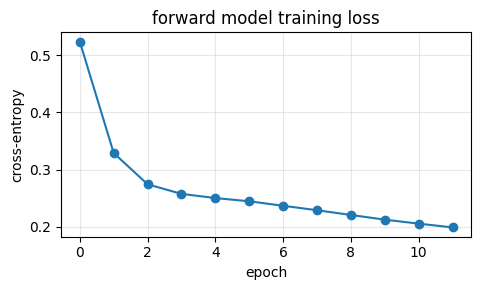

In [7]:
EPOCHS, BATCH, LR = 12, 512, 1e-3
Xt = torch.from_numpy(encode_batch(Xtr, Atr)).float()
Yt = torch.from_numpy(Ytr.reshape(len(Ytr), -1)).long()
Xv = torch.from_numpy(encode_batch(Xva, Ava)).float()
Yv = torch.from_numpy(Yva.reshape(len(Yva), -1)).long()

opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()
losses = []
for ep in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(Xt))
    ep_loss, nb_ = 0.0, 0
    for i in range(0, len(Xt), BATCH):
        idx = perm[i:i + BATCH]
        loss = loss_fn(model(Xt[idx]), Yt[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item(); nb_ += 1
    losses.append(ep_loss / nb_)
    print(f"epoch {ep+1:2d}/{EPOCHS}  loss {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(losses, "o-"); ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy")
ax.set_title("forward model training loss"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("assets/training_loss.png", dpi=110); plt.show()

In [8]:
# 模型质量检查:整体 cell 准确率 vs "输入中不可见 cell"的补全准确率
model.eval()
with torch.no_grad():
    pred = model(Xv).argmax(dim=1)  # (N, 25), 0=free 1=wall
acc_all = (pred == Yv).float().mean().item()
unknown_flat = (Xva.reshape(len(Xva), -1) == UNKNOWN)
acc_inpaint = (pred[unknown_flat] == Yv[unknown_flat]).float().mean().item()
base_rate = max(PRIOR_FREE, 1 - PRIOR_FREE)
print(f"held-out 整体 cell 准确率:            {acc_all:.3f}")
print(f"held-out 不可见 cell 补全准确率:      {acc_inpaint:.3f}  (多数类基线 ≈ {base_rate:.3f})")
print("→ 对'从未见过的 cell',模型的猜测显著优于瞎猜,但远非完美 —— 这正是 model error 的来源。")

held-out 整体 cell 准确率:            0.926
held-out 不可见 cell 补全准确率:      0.893  (多数类基线 ≈ 0.749)
→ 对'从未见过的 cell',模型的猜测显著优于瞎猜,但远非完美 —— 这正是 model error 的来源。


## 6. Visualize:模型"想象"得怎么样?

### 6.1 Predicted vs Actual:下一个局部观测

每行一个样本:**输入窗口**(灰 = UNKNOWN,即记忆里还没见过的 cell)→ **模型预测的下一窗口**(free 概率热图)→ **真实下一窗口**。注意新进入视野的边沿:模型在根据矩形障碍的纹理"脑补"。

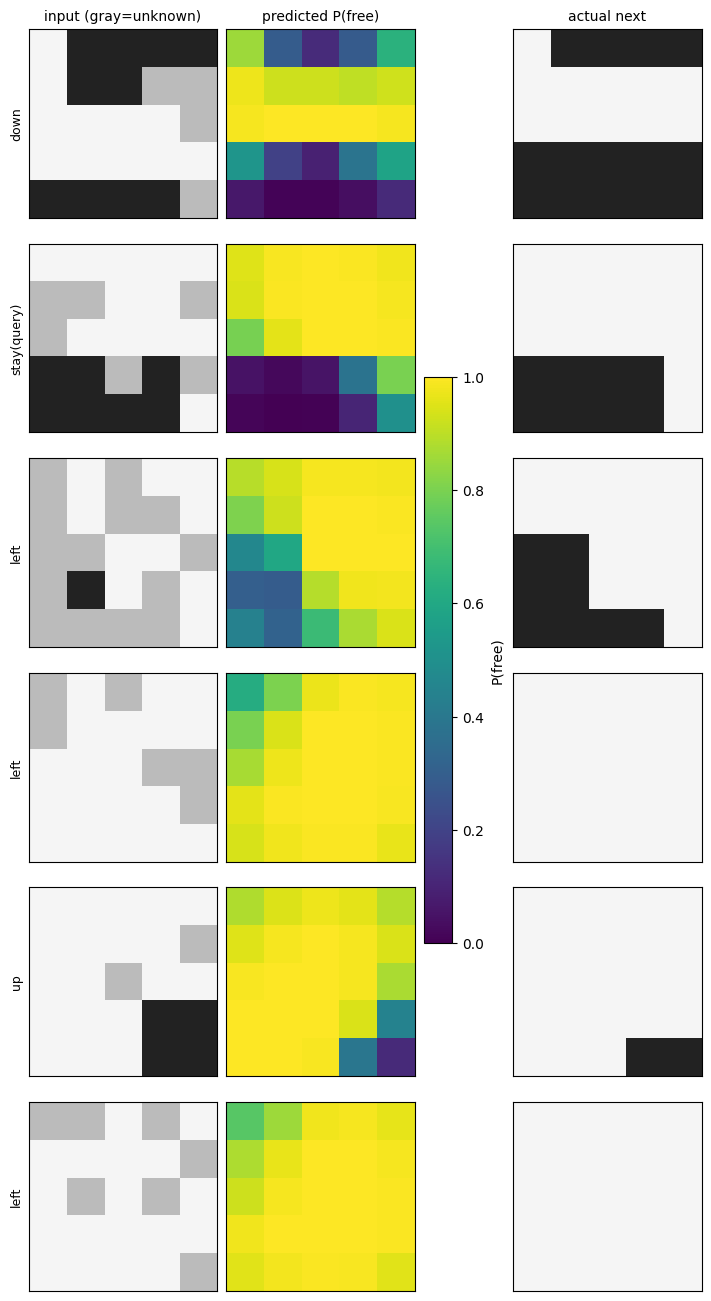

In [9]:
model.eval()
R = R_VIEW
idx_pool = np.where((Xva.reshape(len(Xva), -1) == UNKNOWN).any(axis=1))[0]
show = np.random.default_rng(3).choice(idx_pool, size=6, replace=False)
with torch.no_grad():
    logits = model(torch.from_numpy(encode_batch(Xva[show], Ava[show])).float())
p_free = torch.softmax(logits, dim=1)[:, 0, :].numpy().reshape(-1, 2 * R + 1, 2 * R + 1)

cmap_in = mcolors.ListedColormap(["#bbbbbb", "#f5f5f5", "#222222"])  # UNKNOWN/FREE/WALL
fig, axes = plt.subplots(6, 3, figsize=(7, 13), constrained_layout=True)
for k in range(6):
    axes[k, 0].imshow(Xva[show[k]] + 1, cmap=cmap_in, vmin=0, vmax=2)
    axes[k, 0].set_ylabel(ACT_NAMES[Ava[show[k]]] if Ava[show[k]] < 4 else "stay(query)",
                          fontsize=9)
    im = axes[k, 1].imshow(p_free[k], cmap="viridis", vmin=0, vmax=1)
    axes[k, 2].imshow(Yva[show[k]], cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]),
                      vmin=0, vmax=1)
    for j, t in enumerate(["input (gray=unknown)", "predicted P(free)", "actual next"]):
        axes[k, j].set_xticks([]); axes[k, j].set_yticks([])
        if k == 0: axes[k, j].set_title(t, fontsize=10)
fig.colorbar(im, ax=axes[:, 1], shrink=0.6, label="P(free)")
plt.savefig("assets/model_predictions.png", dpi=110); plt.show()

### 6.2 地图逐渐填充:spatial memory 的生长过程

让 **memory agent** 跑一个 episode,每步记录它的 occupancy map。左:世界全貌 + 真实轨迹;右:agent 脑中的地图(灰 = 未知)。可以看到 **frontier 探索**如何把灰色一点点推开,以及 goal 被看到的那一瞬间,规划立刻从"探索"切换为"直奔目标"。

memory agent: success=True in 79 steps, 41 frames


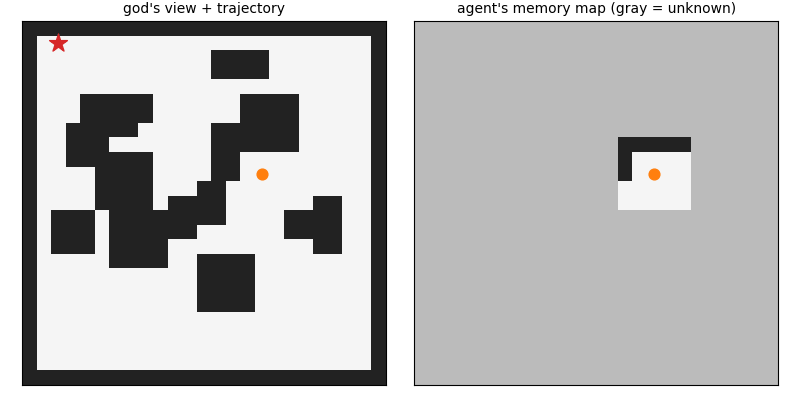

In [10]:
def render_memory_frame(env, mem, traj):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(env.grid, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]))
    axes[0].scatter(*env.goal[::-1], marker="*", c="#d62728", s=180)
    axes[0].set_title("god's view + trajectory", fontsize=10)
    axes[1].imshow(mem.map + 1, cmap=mcolors.ListedColormap(["#bbbbbb", "#f5f5f5", "#222222"]),
                   vmin=0, vmax=2)
    axes[1].set_title("agent's memory map (gray = unknown)", fontsize=10)
    for ax in axes:
        if len(traj) > 1:
            tr = np.array(traj)
            ax.plot(tr[:, 1], tr[:, 0], "-", c="#1f77b4", lw=1.2, alpha=0.8)
        ax.scatter(*traj[-1][::-1], marker="o", c="#ff7f0e", s=60)
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return frame

# 先定义 memory agent(Section 7 会正式介绍三种 agent 并对比)
class MemoryAgent:
    """维护全局 occupancy map;goal 已知则 BFS 直奔,否则 BFS 到最近 frontier 探索。"""
    def __init__(self, H, W, R=2, seed=0):
        self.mem = SpatialMemory(H, W, R)
        self.rng = np.random.default_rng(seed)

    def reset(self, start): self.mem.reset(start)
    def update(self, obs, action, moved): self.mem.update(obs, action, moved)

    def _is_frontier(self, cell):
        r, c = cell
        if self.mem.map[r, c] != FREE:
            return False
        for dr, dc in DELTAS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.mem.H and 0 <= nc < self.mem.W and self.mem.map[nr, nc] == UNKNOWN:
                return True
        return False

    def act(self):
        m, pose = self.mem.map, self.mem.pose
        passable = (m == FREE)
        if self.mem.goal_pos is not None:
            a = bfs_next_action(passable, pose, lambda c: c == self.mem.goal_pos)
            if a is not None:
                return a
        a = bfs_next_action(passable, pose, self._is_frontier)  # 探索最近 frontier
        if a is not None:
            return a
        return int(self.rng.integers(4))  # 兜底(理论上不会走到)

gif_env = GridNavEnv(grid, start, goal, view_radius=R_VIEW, max_steps=300)
gif_agent = MemoryAgent(25, 25, R=R_VIEW, seed=0)
obs = gif_env.reset()
gif_agent.reset(gif_env.start); gif_agent.update(obs, None, False)
traj = [gif_env.pos]; frames = [render_memory_frame(gif_env, gif_agent.mem, traj)]
while True:
    a = gif_agent.act()
    obs, done, info = gif_env.step(a)
    gif_agent.update(obs, a, info["moved"])
    traj.append(gif_env.pos)
    if gif_env.t % 2 == 0 or done:
        frames.append(render_memory_frame(gif_env, gif_agent.mem, traj))
    if done:
        break
imageio.mimsave("assets/map_filling.gif", frames, duration=0.08)
print(f"memory agent: success={info['success']} in {gif_env.t} steps, {len(frames)} frames")
display(Image(filename="assets/map_filling.gif"))

## 7. Evaluate:三种 agent 的正面对比

**三种 agent,同一批测试地图(paired comparison):**

1. **Reactive** —— 无记忆。goal 出现在窗口里就 greedy 逼近;否则保持上一步方向惯性游走(撞墙才换向)。它会重复走老路、在角落振荡 —— 因为没有东西告诉它"这里我来过";
2. **Memory** —— `SpatialMemory` + 保守 BFS:未知 cell 一律视为不可走,goal 未见过就做最近 frontier 探索;
3. **World Model** —— 记忆之上调用 forward model:
   - 对未知 cell 预测 `P(free)`,构造**想象代价图** `cost = 1 + β·(1 − P(free))`,在其上跑 **Dijkstra** —— 允许路径穿越模型认为开阔的未知区域(捷径),而不是死等探索;
   - goal 未知时,frontier 选择用 `想象距离 − gain_w·预测新增可见 free cell 数` 打分(next-best-view 的雏形)—— 优先去模型预测为开阔、信息量大的方向。

**指标**:success rate、平均步数、探索覆盖率(被揭示的 free cell 比例)。

In [11]:
class ReactiveAgent:
    """只看当前 5×5 窗口:goal 可见则 greedy,否则惯性随机游走。没有任何记忆。"""
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.prev = int(self.rng.integers(4))

    def reset(self, start): pass

    def update(self, obs, action, moved):
        self.obs = obs  # 只保留当前帧

    def act(self):
        win = self.obs; c = (win.shape[0] - 1) // 2
        goals = np.argwhere(win == 2)
        if len(goals):  # goal 在视野内:greedy 逼近(绕开看得见的墙)
            g = goals[0]
            best, bd = None, 1e9
            for a, (dr, dc) in enumerate(DELTAS):
                if win[c + dr, c + dc] != 1:
                    d = abs(c + dr - g[0]) + abs(c + dc - g[1])
                    if d < bd:
                        bd, best = d, a
            return best
        # 探索:保持方向惯性,撞墙或偶尔随机换向
        dr, dc = DELTAS[self.prev]
        if self.rng.random() < 0.15 or win[c + dr, c + dc] == 1:
            free_dirs = [a for a, (dr, dc) in enumerate(DELTAS) if win[c + dr, c + dc] != 1]
            self.prev = int(self.rng.choice(free_dirs))
        return self.prev

class WorldModelAgent(MemoryAgent):
    """Memory + learned forward model:在'想象代价图'上规划,穿越预测为开阔的未知区域。"""
    def __init__(self, H, W, model, prior_free, R=2, seed=0, beta=3.0, gain_w=0.3):
        super().__init__(H, W, R, seed)
        self.model, self.prior_free = model, prior_free
        self.beta, self.gain_w = beta, gain_w

    def _predict_windows(self, cells):
        """批量查询模型:站在每个 cell 上'原地查询' -> 每个 cell 的 P(free) 热图。"""
        wins = np.stack([window_of(self.mem.map, r, c, self.mem.R) for r, c in cells])
        x = torch.from_numpy(encode_batch(wins, np.full(len(cells), STAY))).float()
        with torch.no_grad():
            p = torch.softmax(self.model(x), dim=1)[:, 0, :].numpy()
        return wins, p

    def _imagined_cost(self):
        m = self.mem.map
        cost = np.where(m == WALL, np.inf, np.where(m == FREE, 1.0, np.nan)).astype(float)
        cost[np.isnan(cost)] = 1.0 + self.beta * (1 - self.prior_free)  # 深层未知:先验
        known = (m != UNKNOWN)
        dil = known.copy()
        for dr in range(-self.mem.R, self.mem.R + 1):  # 窗口与已知区相交的未知 cell
            for dc in range(-self.mem.R, self.mem.R + 1):
                dil |= np.roll(np.roll(known, dr, 0), dc, 1)
        cells = [tuple(c) for c in np.argwhere((m == UNKNOWN) & dil)]
        if cells:
            _, p = self._predict_windows(cells)
            ctr = (2 * self.mem.R + 1) ** 2 // 2
            for (r, c), pk in zip(cells, p):
                cost[r, c] = 1.0 + self.beta * (1 - pk[ctr])
        return cost

    def act(self):
        m, pose = self.mem.map, self.mem.pose
        cost = self._imagined_cost()
        dist, prev = dijkstra(cost, pose)
        # 1) goal 已知:在想象地图上直奔(允许抄模型预测为开阔的近路)
        if self.mem.goal_pos is not None and np.isfinite(dist[self.mem.goal_pos]):
            a = first_action_to(prev, pose, self.mem.goal_pos)
            if a is not None:
                return a
        # 2) frontier 选择:想象距离 - gain_w * 预测新增可见 free 数
        frontiers = [tuple(c) for c in np.argwhere(m == FREE) if self._is_frontier(tuple(c))]
        frontiers = [f for f in frontiers if np.isfinite(dist[f])]
        if frontiers:
            wins, p = self._predict_windows(frontiers)
            best, bs = None, np.inf
            for f, w, pk in zip(frontiers, wins, p):
                gain = pk[(w == UNKNOWN).reshape(-1)].sum()  # 预期信息增益
                s = dist[f] - self.gain_w * gain
                if s < bs:
                    bs, best = s, f
            a = first_action_to(prev, pose, best)
            if a is not None:
                return a
        return super().act()  # 兜底:退化为保守 BFS

def run_episode(env, agent):
    obs = env.reset()
    agent.reset(env.start); agent.update(obs, None, False)
    traj = [env.pos]
    info = {"success": False, "moved": False}
    for _ in range(env.max_steps):
        a = agent.act()
        obs, done, info = env.step(a)
        agent.update(obs, a, info["moved"])
        traj.append(env.pos)
        if done:
            break
    return {"success": info["success"], "steps": env.t, "traj": traj}

def coverage(env, traj):
    """探索覆盖率:轨迹沿途视野扫过的 free cell 比例(agent 无关,评估器计算)。"""
    known = np.zeros_like(env.grid, bool); R = env.R
    for r, c in traj:
        r0, r1 = max(0, r - R), min(env.H, r + R + 1)
        c0, c1 = max(0, c - R), min(env.W, c + R + 1)
        known[r0:r1, c0:c1] = True
    free = (env.grid == 0)
    return float((known & free).sum() / free.sum())

def evaluate(agent_fn, maps, max_steps=300):
    rows = []
    for i, (g, s, gl) in enumerate(maps):
        env = GridNavEnv(g, s, gl, view_radius=R_VIEW, max_steps=max_steps)
        res = run_episode(env, agent_fn(seed=100 + i))
        rows.append({"success": res["success"], "steps": res["steps"],
                     "coverage": coverage(env, res["traj"]), "traj": res["traj"]})
    return rows

test_rng = np.random.default_rng(2000)
test_maps = [generate_map(25, 25, 14, test_rng, min_dist=20) for _ in range(12)]
print(f"{len(test_maps)} 张测试地图就绪(与训练/验证地图完全不同的 seed)")

12 张测试地图就绪(与训练/验证地图完全不同的 seed)


agent                     success  avg steps   coverage
Reactive                     0.58      211.5       0.56
Memory (BFS)                 1.00      105.2       0.67
World Model (Ours)           1.00       88.0       0.70


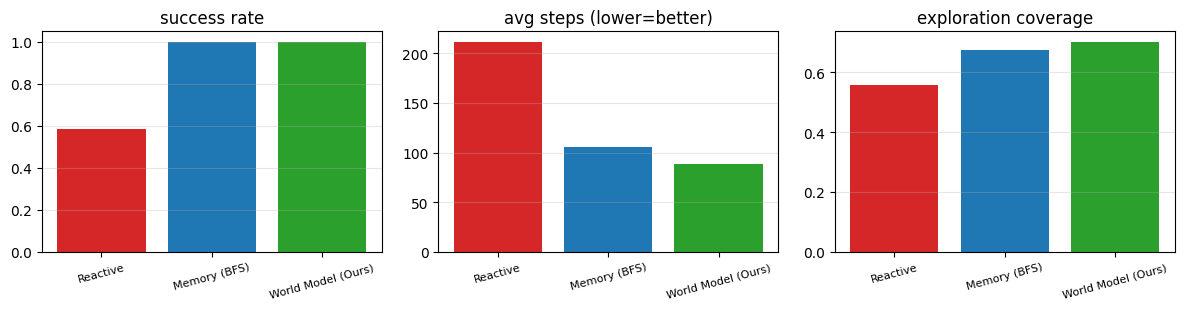

In [12]:
results = {
    "Reactive":            evaluate(lambda seed: ReactiveAgent(seed), test_maps),
    "Memory (BFS)":        evaluate(lambda seed: MemoryAgent(25, 25, R_VIEW, seed), test_maps),
    "World Model (Ours)":  evaluate(lambda seed: WorldModelAgent(25, 25, model, PRIOR_FREE,
                                                                 R_VIEW, seed), test_maps),
}
print(f"{'agent':22s} {'success':>10s} {'avg steps':>10s} {'coverage':>10s}")
summary = {}
for name, rows in results.items():
    succ = np.mean([r["success"] for r in rows])
    steps = np.mean([r["steps"] for r in rows])
    cov = np.mean([r["coverage"] for r in rows])
    summary[name] = (succ, steps, cov)
    print(f"{name:22s} {succ:>10.2f} {steps:>10.1f} {cov:>10.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, k, title in zip(axes, range(3), ["success rate", "avg steps (lower=better)",
                                          "exploration coverage"]):
    vals = [summary[n][k] for n in summary]
    ax.bar(range(3), vals, color=["#d62728", "#1f77b4", "#2ca02c"])
    ax.set_xticks(range(3)); ax.set_xticklabels(list(summary), rotation=15, fontsize=8)
    ax.set_title(title); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("assets/metrics.png", dpi=110); plt.show()

**怎么读这张表:**

- **Reactive** 的成功率显著低、步数封顶 —— 不是它"笨",而是 partial observability 下没有 memory 就没有状态,greedy 在墙角振荡是必然的;
- **Memory** 用 frontier 探索换来接近满分成功率,但代价是大量步数:它把未知视为墙,goal 方向再近也必须先绕已知路;
- **World Model** 用模型的猜测把规划伸进未知区域:frontier 的"想象距离"穿过预测为开阔的未知区,goal 一旦出现则直奔 —— 以**显著更少的步数**到达 goal,覆盖率却不降(探索得更"准",不是更"少")。这正是"model 让规划超越已见区域"的直接证据。但这份收益全部押在模型的可信度上 —— 下一节把它放到 OOD 世界里检验。

### 7.1 同一张地图上的轨迹对比

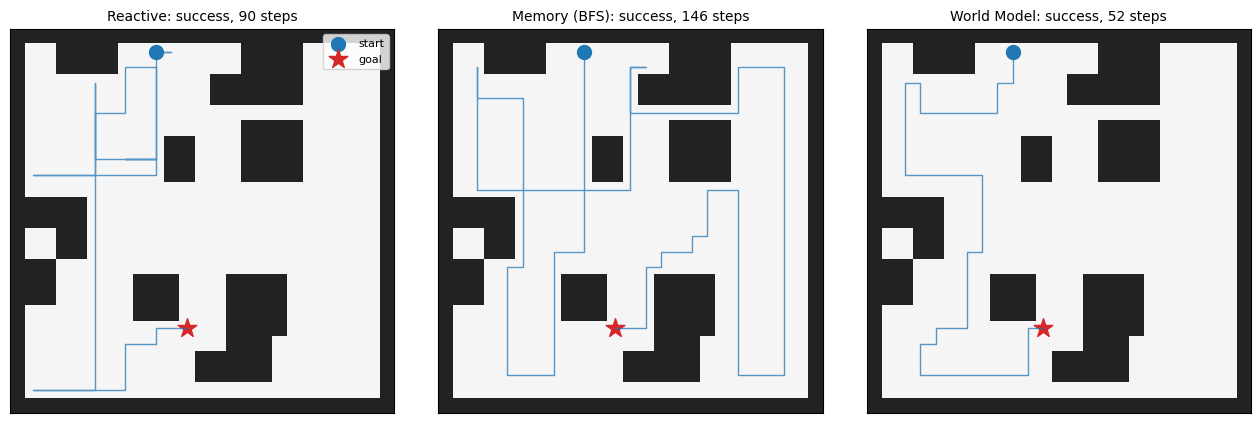

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
g, s, gl = test_maps[0]
for ax, (name, maker) in zip(axes, [
        ("Reactive", lambda seed: ReactiveAgent(seed)),
        ("Memory (BFS)", lambda seed: MemoryAgent(25, 25, R_VIEW, seed)),
        ("World Model", lambda seed: WorldModelAgent(25, 25, model, PRIOR_FREE, R_VIEW, seed))]):
    env = GridNavEnv(g, s, gl, view_radius=R_VIEW, max_steps=300)
    res = run_episode(env, maker(0))
    tr = np.array(res["traj"])
    ax.imshow(g, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]))
    ax.plot(tr[:, 1], tr[:, 0], "-", c="#1f77b4", lw=1.0, alpha=0.75)
    ax.scatter(*s[::-1], marker="o", c="#1f77b4", s=100, label="start")
    ax.scatter(*gl[::-1], marker="*", c="#d62728", s=200, label="goal")
    ax.set_title(f"{name}: {'success' if res['success'] else 'FAIL'}, {res['steps']} steps",
                 fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.savefig("assets/agent_paths.png", dpi=110); plt.show()

## 8. Experiment:当世界统计改变 —— World Model 的 OOD 风险

**Why this experiment:** world model agent 的全部优势来自模型对"未见区域统计规律"的猜测。我们的模型是在**大矩形障碍物**地图上训练的。如果把测试世界换成**细碎噪声障碍**(salt-and-pepper,训练分布从未见过),会发生什么?

我们分两层检验:**模型层面**(8.1)—— 同一个 forward model 在 OOD 窗口上的 per-cell 预测精度;**行为层面**(8.2)—— memory 与 world model agent 在 OOD 地图上的任务指标。预期模型精度显著下滑;而行为层面是否跟着崩,取决于 closed-loop replanning 能不能吸收 model error。

In [14]:
def generate_ood_map(H, W, rng, p_wall=0.22, min_dist=20, max_tries=300):
    """salt-and-pepper 噪声障碍:与训练用的矩形障碍物统计分布完全不同(OOD)。"""
    for _ in range(max_tries):
        grid = (rng.random((H, W)) < p_wall).astype(np.int64)
        grid[0, :] = grid[-1, :] = 1; grid[:, 0] = grid[:, -1] = 1
        frees = np.argwhere(grid == 0)
        i, j = rng.choice(len(frees), size=2, replace=False)
        s, gl = tuple(frees[i]), tuple(frees[j])
        if abs(s[0] - gl[0]) + abs(s[1] - gl[1]) < min_dist:
            continue
        if _reachable(grid, s, gl):
            return grid, s, gl
    raise RuntimeError("ood map generation failed")

ood_rng = np.random.default_rng(3000)
ood_maps = [generate_ood_map(25, 25, ood_rng) for _ in range(8)]

# --- 8.1 模型层面:同一个 forward model,换分布后 per-cell 预测精度 ---
def sample_windows(maps, per_map, R, seed):
    """从给定地图集采样 masked (window, STAY) 查询样本,测 in/out-of-dist 精度。"""
    rng = np.random.default_rng(seed)
    W5, Y = [], []
    for g, _, _ in maps:
        frees = np.argwhere(g == 0)
        for _ in range(per_map):
            r, c = frees[rng.integers(len(frees))]
            w = window_of(g, r, c, R).astype(np.int64)
            w[rng.random(w.shape) < rng.uniform(0.0, 0.6)] = UNKNOWN
            W5.append(w); Y.append(window_of(g, r, c, R))
    return np.array(W5), np.array(Y)

def cell_accuracy(maps, seed):
    W5, Y = sample_windows(maps, 400, R_VIEW, seed)
    x = torch.from_numpy(encode_batch(W5, np.full(len(W5), STAY))).float()
    with torch.no_grad():
        pred = model(x).argmax(dim=1).numpy()
    yf = Y.reshape(len(Y), -1)
    unk = (W5.reshape(len(W5), -1) == UNKNOWN)
    return float((pred == yf).mean()), float((pred[unk] == yf[unk]).mean())

in_rng = np.random.default_rng(4000)
in_dist_maps = [generate_map(25, 25, 14, in_rng, min_dist=20) for _ in range(8)]
a_in = cell_accuracy(in_dist_maps, seed=1)
a_ood = cell_accuracy(ood_maps, seed=2)
print(f"{'distribution':28s} {'overall acc':>12s} {'unseen-cell acc':>16s}")
print(f"{'in-dist (rect obstacles)':28s} {a_in[0]:>12.3f} {a_in[1]:>16.3f}")
print(f"{'OOD (salt-and-pepper)':28s} {a_ood[0]:>12.3f} {a_ood[1]:>16.3f}")
print("→ 模型没变,世界变了:对'未见 cell'的猜测精度明显下滑 —— 这就是 OOD 的定量化。")

distribution                  overall acc  unseen-cell acc
in-dist (rect obstacles)            0.957            0.893
OOD (salt-and-pepper)               0.829            0.731
→ 模型没变,世界变了:对'未见 cell'的猜测精度明显下滑 —— 这就是 OOD 的定量化。


**模型层面:精度显著下滑。** 矩形世界的先验(大块连通障碍、平直边缘)在噪声世界里完全不成立,模型对未见 cell 的补全准确率掉了十几个点。**模型的"想象"只能在训练分布的内插邻域内被信任** —— 这是一切 learned world model 的通用约束。

### 8.2 行为层面:model error 被 closed-loop 吸收了吗?

agent (OOD test maps)       success  avg steps   coverage
Memory (BFS)                   1.00      118.5       0.73
World Model (OOD)              1.00       95.5       0.65


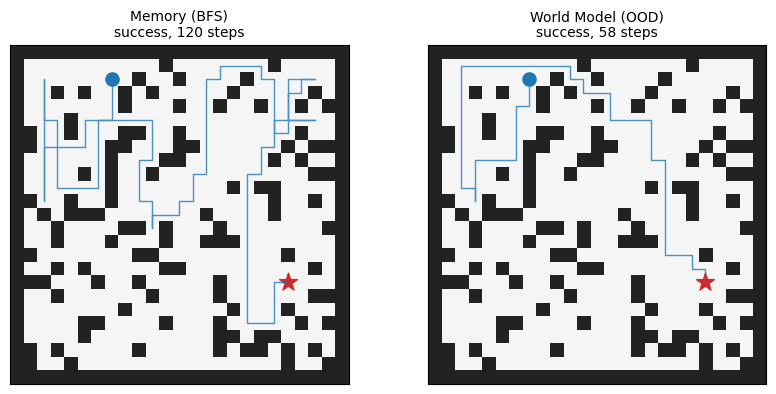

In [15]:
ood_results = {
    "Memory (BFS)":       evaluate(lambda seed: MemoryAgent(25, 25, R_VIEW, seed), ood_maps),
    "World Model (OOD)":  evaluate(lambda seed: WorldModelAgent(25, 25, model, PRIOR_FREE,
                                                                R_VIEW, seed), ood_maps),
}
print(f"{'agent (OOD test maps)':24s} {'success':>10s} {'avg steps':>10s} {'coverage':>10s}")
for name, rows in ood_results.items():
    print(f"{name:24s} {np.mean([r['success'] for r in rows]):>10.2f} "
          f"{np.mean([r['steps'] for r in rows]):>10.1f} "
          f"{np.mean([r['coverage'] for r in rows]):>10.2f}")

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
for ax, (name, rows) in zip(axes, ood_results.items()):
    ax.imshow(ood_maps[0][0], cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]))
    tr = np.array(rows[0]["traj"])
    ax.plot(tr[:, 1], tr[:, 0], "-", c="#1f77b4", lw=1.0, alpha=0.8)
    ax.scatter(*ood_maps[0][1][::-1], marker="o", c="#1f77b4", s=90)
    ax.scatter(*ood_maps[0][2][::-1], marker="*", c="#d62728", s=180)
    ax.set_title(f"{name}\n{'success' if rows[0]['success'] else 'FAIL'}, "
                 f"{rows[0]['steps']} steps", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("assets/ood_comparison.png", dpi=110); plt.show()

**典型观察:** 尽管模型的预测精度在 OOD 下明显变差(8.1),world model agent 的任务指标仍与 memory 相当、甚至更好 —— 因为 **closed-loop replanning** 每步都用最新观测校正想象地图,猜错的代价只是多绕几步(与 Lab 4 的 open vs closed 结论一致)。

但**不要误读为"OOD 无害"**:这个实验里猜错的代价低,是因为世界密度不高、且每步都重规划。在更密集的世界、open-loop 执行(Exercise 3 的思路)或安全关键场景下,8.1 里那种精度下滑会直接转化为失败。工程上的标准解法是 **uncertainty-aware model**(ensemble / 置信度校准):模型不自信时自动退回 memory 的保守规划 —— 只信亲眼所见。

In [16]:
import resource
elapsed = time.time() - T0
peak_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024 / 1024
print(f"notebook 总耗时(至本 cell): {elapsed:.1f} s | 峰值内存: {peak_mb:.0f} MB | device: CPU")

notebook 总耗时(至本 cell): 23.5 s | 峰值内存: 595 MB | device: CPU


## 9. Questions(思考题)

1. Reactive agent 的失败模式中,有多少来自"没有地图"、有多少来自"没有动作历史(连自己上一秒往哪走都不记得)"?给 reactive agent 只加一个"上一步动作"的输入能救回多少成功率?
2. Memory agent 把 UNKNOWN 视为不可走(保守);如果把 UNKNOWN 视为 FREE(乐观,类似 D* Lite 的初始假设),不做任何学习,能追平 world model agent 吗?在什么地图统计下乐观策略会崩?
3. World model agent 撞墙后靠 closed-loop replanning 自愈。如果把模型预测缓存起来不更新(open-loop 想象),失败模式会变成什么样?(联系 Lab 4 的 open vs closed 对比)
4. 本 Lab 的 odometry 是无噪声的。真实 robot 的轮式里程计会漂移 —— 地图会出现重影、撕裂。这正是 **SLAM** 要解决的问题:除了建图,还要**同时**校正位姿估计。

### ✏️ Exercise 1 — 视野大小:partial observability 的量化

把 `R_VIEW` 从 2(5×5)改成 1(3×3)或 3(7×7),重跑 Section 7 的对比。注意 `ForwardModel` 的输入维度依赖窗口大小,dataset 与模型都要重建。视野变小时三种 agent 的差距如何变化?

In [17]:
# YOUR CODE HERE
# 提示:R_VIEW = 1 → 重跑 3.3 dataset → 重建 ForwardModel(R=1) → 重训 → 重新 evaluate

### ✏️ Exercise 2 — odometry noise:当地图开始"漂移"

让 env 以 5% 概率"打滑":动作实际无效,但 `info["moved"]` 仍上报 True(里程计说谎)。继承 `GridNavEnv` 覆写 `step`,然后只重跑 memory agent,把它的最终记忆地图与真值叠画出来 —— 你会看到地图错位、重影。这就是 VSLAM 存在的原因。

In [18]:
# YOUR CODE HERE
# 提示:class SlipperyEnv(GridNavEnv): 在 step 里用 self.rng 决定本步是否打滑

### ✏️ Exercise 3 — 更大地图 + 移动障碍物

把地图放大到 41×41,并在 env 里加 2 个每步随机游走的动态障碍(撞上会挡住 agent)。memory map 的"见过即真"假设在动态世界里会失效 —— 需要给地图加"遗忘"或时间戳。思考:world model 能否学会预测障碍物的运动?这与视频预测 Lab 的联系是什么?

In [19]:
# YOUR CODE HERE

## 10. Takeaways

- **Partial observability 是导航的第一性问题**:当前 observation 不足以决策时,agent 必须把历史压缩成内部状态 —— 这就是 state estimation;
- **Memory(occupancy map)已经是一种空间智能**:它把 episodic 的观测流变成 allocentric 的持久结构,让 BFS/A* 等图规划成为可能;frontier 探索 + 保守规划即可拿到接近满分的成功率;
- **World model 让规划超越已见区域**:对未知 cell 的占据预测 → 想象代价图 → 捷径与更聪明的 frontier 选择。收益是步数,代价是 model error;
- **Model error 在 closed-loop 下可校正,在 OOD 下会放大**:世界统计改变时,模型的自信猜测变成系统性错误,保守的 memory 反而更稳 —— uncertainty-aware model 是标准答案;
- **本 Lab 的链路 Observation → State Estimation → Memory/Map → World Model → Planning → Action,就是认知地图(cognitive mapping)、Active Neural SLAM 与 Dreamer 系列在 2D 格子里的最小实现**。下一步(Lab 9):把规划换成学习得到的 policy,world model 开始为策略训练提供想象数据。